In [61]:
from os import rename

import numpy as np
from datetime import datetime
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [54]:
# E-mini contract
file_path = '../data/raw/E-mini_ES.xlsx'

contracts = ['ESM6', 'ESU6', 'ESZ6']

fut_dfs = {}
for contract in contracts:
    df = pd.read_excel(file_path, sheet_name=contract)
    # df = df.dropna()
    df = df.dropna(subset=['Date'])
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date')
    df = df.sort_index()

    fut_dfs[contract] = df
print(fut_dfs)

{'ESM6':             Last Price  Open Interest     Volume
Date                                            
2023-08-17     4784.00            NaN        NaN
2023-08-18     4781.00            NaN        NaN
2023-08-21     4812.00            NaN        NaN
2023-08-22     4799.00            NaN        NaN
2023-08-23     4847.00            NaN        NaN
...                ...            ...        ...
2026-04-02     6622.25      1909967.0  1965184.0
2026-04-03     6622.25      1908515.0    72058.0
2026-04-06     6651.00      1897600.0  1103916.0
2026-04-07     6656.75      1916320.0  1997800.0
2026-04-08     6815.25            NaN   245770.0

[668 rows x 3 columns], 'ESU6':             Last Price  Open Interest  Volume
Date                                         
2023-08-17     4805.00            NaN     NaN
2023-08-18     4802.00            NaN     NaN
2023-08-21     4833.00            NaN     NaN
2023-08-22     4820.00            NaN     NaN
2023-08-23     4868.00            NaN     NaN

In [55]:
fut_multi = pd.concat(fut_dfs, axis=1, sort=False)
fut_multi = fut_multi.swaplevel(0, 1, axis=1).sort_index()
fut_multi

,Last Price,Open Interest,Volume,Last Price,Open Interest,Volume,Last Price,Open Interest,Volume
,ESM6,ESM6,ESM6,ESU6,ESU6,ESU6,ESZ6,ESZ6,ESZ6
Date,,,,,,,,,
2021-09-16,NaN,NaN,NaN,NaN,NaN,NaN,4413.8,NaN,NaN
2021-09-17,NaN,NaN,NaN,NaN,NaN,NaN,4375.1,NaN,NaN
2021-09-20,NaN,NaN,NaN,NaN,NaN,NaN,4298.5,NaN,NaN
2021-09-21,NaN,NaN,NaN,NaN,NaN,NaN,4294.5,NaN,NaN
2021-09-22,NaN,NaN,NaN,NaN,NaN,NaN,4333.5,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2026-04-02,6622.25,1909967.0,1965184.0,6672.25,15911.0,3773.0,6722.0,882.0,2.0
2026-04-03,6622.25,1908515.0,72058.0,6672.25,15900.0,165.0,6722.0,882.0,NaN


In [58]:
fut_price = fut_multi['Last Price'].dropna()
fut_price

,ESM6,ESU6,ESZ6
Date,,,
2023-08-17,4784.00,4805.00,4827.0
2023-08-18,4781.00,4802.00,4824.0
2023-08-21,4812.00,4833.00,4855.0
2023-08-22,4799.00,4820.00,4842.0
2023-08-23,4847.00,4868.00,4890.0
...,...,...,...
2026-04-02,6622.25,6672.25,6722.0
2026-04-03,6622.25,6672.25,6722.0
2026-04-06,6651.00,6701.25,6756.0


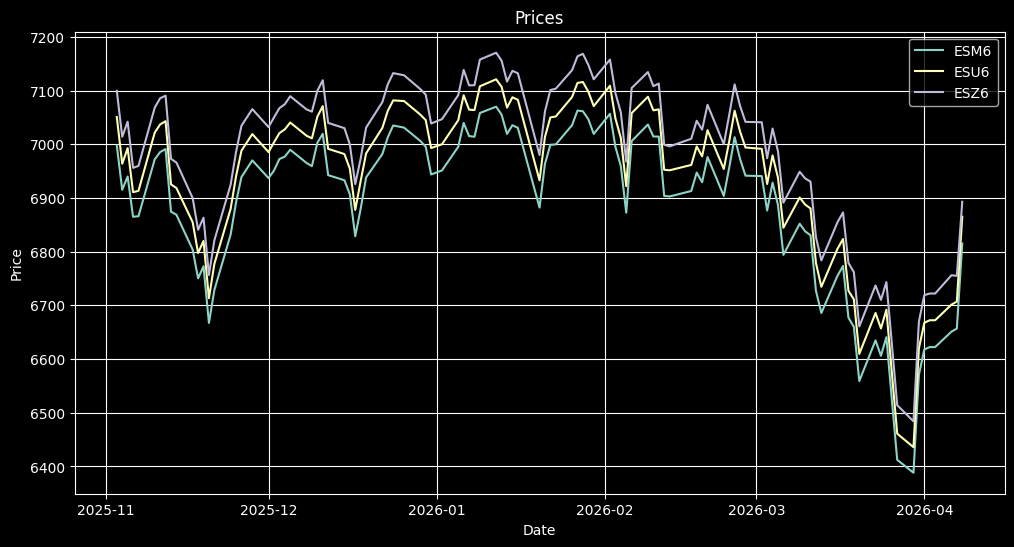

In [68]:
contracts = ['ESM6', 'ESU6', 'ESZ6']
df_plot = fut_price.loc['2025-11-01':]
plt.figure(figsize=(12,6))

for c in contracts:
    plt.plot(df_plot.index, df_plot[c], label=c)

plt.title('Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

plt.show()

contango (r>q)

In [60]:
fut_price.to_excel('../data/processed/E-mini_price.xlsx')